In [ ]:
a346915891113ed546e8d256a521cbb9

In [7]:
import requests , json , pandas as pd
key = "a346915891113ed546e8d256a521cbb9"
def Weather(lat,lon):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}"

    data = requests.get(url)
    if data.status_code == 200 :
        final = data.json()
        
        new = json.dumps(final , indent=5)
        # print(new)

        base = final["base"]
        name = final["name"]
        temp = final["main"]["temp"]
        temp_min = final["main"]["temp_min"]
        temp_max = final["main"]["temp_max"]

        return [base , name , temp , temp_min , temp_max]
surat = [21.1702 , 72.8311]
jamnagar = [22.4729 , 70.0667]
ahm = [23.033863,72.585022]
citys = [surat , jamnagar , ahm]

details = []

for i in citys :
    row = Weather(i[0] , i[1])
    details.append(row)

df = pd.DataFrame(details, columns=["base" , "name" , "temp" , "temp_min" , "temp_max"])

df

,base,name,temp,temp_min,temp_max
0,stations,Surat,305.45,305.45,305.45
1,stations,Jamnagar,304.26,304.26,304.26
2,stations,Ahmedabad,303.16,303.16,303.16


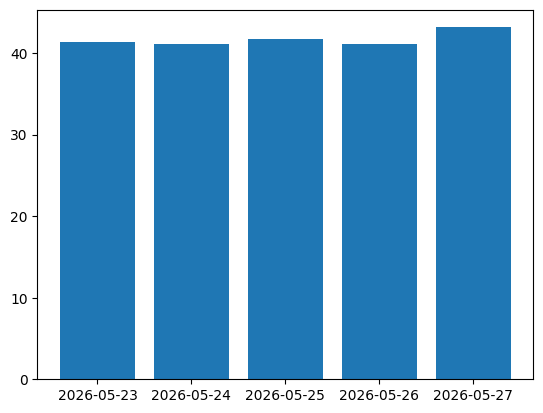

In [21]:
import requests , json , pandas as pd 
import matplotlib.pyplot as plt
key = "a346915891113ed546e8d256a521cbb9"
def Weather(lat,lon):
    url = f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={key}"

    data = requests.get(url)
    if data.status_code == 200 :
        final = data.json()
        
        new = json.dumps(final , indent=5)
        # print(new)

        dt = []
        t = []
        desc = []

        for i in final["list"] :
            dt.append(i["dt_txt"])
            t.append(i["main"]["temp"])
            desc.append(i["weather"][0]["description"])

            
        
        return dt , t  ,desc
# surat = [21.1702 , 72.8311]
# jamnagar = [22.4729 , 70.0667]
# ahm = [23.033863,72.585022]
# citys = [surat , jamnagar , ahm]



# for i in citys :
#     row = Weather(23.033863,72.585022)
#     details.append(row)

dt , t , desc = Weather(23.033863,72.585022)

date = []
time = []

for i in dt :
    date.append(i.split(" ")[0])
    time.append(i.split(" ")[1])

cal = []
fal = []
for i in t :
    cal.append( float(i) - 273.5 )

    f = (float(i) - 273.5)*(9/5) + 32
    fal.append(f)

df = pd.DataFrame({
    "Date" : date ,
    "time" : time,
    "DESC" : desc,
    "TEMP in C" : cal,
    "TEMP in F" : fal,
    "TEMP in CAL" : t
})

x = df[ df["time"] == "12:00:00" ]["Date"]
y = df[ df["time"] == "12:00:00" ]["TEMP in C"]

plt.bar(x,y)
plt.show()
